# <center>**Trabajo Práctico Número 2**</center>

### <center>**Recorridos en Ecobicis - Año 2024**</center>

#### <center>Análisis de datos - CEIA, Fiuba</center>

---

**Integrantes del grupo**

- Espínola, Carla
- Gambarte, Antonella

---


In [225]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [226]:
df_recorridos = pd.read_csv("../tp_datos/recorridos_data.csv")
print(df_recorridos.shape)
df_recorridos.head()

(3559283, 23)


,id_recorrido,duracion_recorrido,fecha_origen_recorrido,id_estacion_origen,nombre_estacion_origen,direccion_estacion_origen,long_estacion_origen,lat_estacion_origen,fecha_destino_recorrido,id_estacion_destino,...,lat_estacion_destino,id_usuario,modelo_bicicleta,genero,edad_usuario,fecha_alta,has_dni,mes_origen,dia_semana_origen,edad_usuario_redondeada
0,20428222,568,2024-01-23 18:36:00,513,308 - SAN MARTIN II,Av. San Martín 5129,-58.490739,-34.597130,2024-01-23 18:45:28,498,...,-34.586598,992557,FIT,MALE,NaN,NaN,NaN,1,Tuesday,NaN
1,20431744,1355,2024-01-23 22:41:20,460,133 - BEIRO Y SEGUROLA,Segurola 3194,-58.511930,-34.607500,2024-01-23 23:03:55,382,...,-34.605431,320782,FIT,FEMALE,NaN,NaN,NaN,1,Tuesday,NaN
2,20429936,0,2024-01-23 20:06:22,467,328 - SARMIENTO II,Sarmiento 2037,-58.395893,-34.605514,2024-01-23 20:06:22,6,...,-34.628526,828678,FIT,FEMALE,NaN,NaN,NaN,1,Tuesday,NaN
3,20429976,0,2024-01-23 20:08:17,382,204 - Biarritz,Biarritz 2403,-58.477255,-34.605431,2024-01-23 20:08:17,460,...,-34.607500,320782,ICONIC,FEMALE,NaN,NaN,NaN,1,Tuesday,NaN
4,20424802,680,2024-01-23 15:18:39,137,137 - AZOPARDO Y CHILE,AZOPARDO 700,-58.367492,-34.615598,2024-01-23 15:29:59,150,...,-34.618755,861425,FIT,FEMALE,NaN,NaN,NaN,1,Tuesday,NaN


In [227]:
df_recorridos.columns

Index(['id_recorrido', 'duracion_recorrido', 'fecha_origen_recorrido',
       'id_estacion_origen', 'nombre_estacion_origen',
       'direccion_estacion_origen', 'long_estacion_origen',
       'lat_estacion_origen', 'fecha_destino_recorrido', 'id_estacion_destino',
       'nombre_estacion_destino', 'direccion_estacion_destino',
       'long_estacion_destino', 'lat_estacion_destino', 'id_usuario',
       'modelo_bicicleta', 'genero', 'edad_usuario', 'fecha_alta', 'has_dni',
       'mes_origen', 'dia_semana_origen', 'edad_usuario_redondeada'],
      dtype='object')

### Eliminación de columnas

Al analizar las columnas disponibles y considerando el objetivo de predecir la duración del recorrido, identificamos la necesidad de eliminar aquellas variables que contienen información del futuro o que no estaría disponible en el momento de hacer la predicción.

Además, analizando los datos referidos a la ubicación de las estaciones, elegimos utilizar las coordenadas por lo que las direcciones van a ser eliminadas. Tambien vamos usar los id de las estaciones para identificarlas, por lo que el nombre ya no es necesario.


In [228]:
df_recorridos = df_recorridos.drop(['fecha_destino_recorrido'], axis=1) 
df_recorridos = df_recorridos.drop(['id_estacion_destino'], axis=1) 
df_recorridos = df_recorridos.drop(['nombre_estacion_destino'], axis=1) 
df_recorridos = df_recorridos.drop(['direccion_estacion_destino'], axis=1) 
df_recorridos = df_recorridos.drop(['long_estacion_destino'], axis=1) 
df_recorridos = df_recorridos.drop(['lat_estacion_destino'], axis=1) 

df_recorridos = df_recorridos.drop(['direccion_estacion_origen'], axis=1)  
df_recorridos = df_recorridos.drop(['nombre_estacion_origen'], axis=1) 


df_recorridos.head()

,id_recorrido,duracion_recorrido,fecha_origen_recorrido,id_estacion_origen,long_estacion_origen,lat_estacion_origen,id_usuario,modelo_bicicleta,genero,edad_usuario,fecha_alta,has_dni,mes_origen,dia_semana_origen,edad_usuario_redondeada
0,20428222,568,2024-01-23 18:36:00,513,-58.490739,-34.597130,992557,FIT,MALE,NaN,NaN,NaN,1,Tuesday,NaN
1,20431744,1355,2024-01-23 22:41:20,460,-58.511930,-34.607500,320782,FIT,FEMALE,NaN,NaN,NaN,1,Tuesday,NaN
2,20429936,0,2024-01-23 20:06:22,467,-58.395893,-34.605514,828678,FIT,FEMALE,NaN,NaN,NaN,1,Tuesday,NaN
3,20429976,0,2024-01-23 20:08:17,382,-58.477255,-34.605431,320782,ICONIC,FEMALE,NaN,NaN,NaN,1,Tuesday,NaN
4,20424802,680,2024-01-23 15:18:39,137,-58.367492,-34.615598,861425,FIT,FEMALE,NaN,NaN,NaN,1,Tuesday,NaN


In [229]:
df_recorridos['fecha_origen_recorrido'] = pd.to_datetime(df_recorridos['fecha_origen_recorrido'])
df_recorridos['fecha_alta'] = pd.to_datetime(df_recorridos['fecha_alta'])
df_recorridos['has_dni'] = df_recorridos['has_dni'].map({'Yes': True, 'No': False, np.nan: np.nan})
df_recorridos['modelo_bicicleta'] = df_recorridos['modelo_bicicleta'].astype('category')
df_recorridos['genero'] = df_recorridos['genero'].astype('category')

df_recorridos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3559283 entries, 0 to 3559282
Data columns (total 15 columns):
 #   Column                   Dtype         
---  ------                   -----         
 0   id_recorrido             int64         
 1   duracion_recorrido       int64         
 2   fecha_origen_recorrido   datetime64[ns]
 3   id_estacion_origen       int64         
 4   long_estacion_origen     float64       
 5   lat_estacion_origen      float64       
 6   id_usuario               int64         
 7   modelo_bicicleta         category      
 8   genero                   category      
 9   edad_usuario             float64       
 10  fecha_alta               datetime64[ns]
 11  has_dni                  object        
 12  mes_origen               int64         
 13  dia_semana_origen        object        
 14  edad_usuario_redondeada  float64       
dtypes: category(2), datetime64[ns](2), float64(4), int64(5), object(2)
memory usage: 359.8+ MB


Ahora dividimos en train y test


In [230]:
X = df_recorridos.drop("duracion_recorrido", axis=1)
y = df_recorridos["duracion_recorrido"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Outliers

Para este dataset habíamos detectado outliers en la variable edad. Recordemos que para este caso existían valores atípicos(por ejemplo, valores por arriba de los 100 años) por lo que procedemos a eliminarlos.
Dado el dominio del problema y las reglamentaciones vigentes para el uso de ecobicis, la edad mínima para su uso es de 16 años. Tomamos como edad máxima 80 años.


In [231]:
# Creamos una mascara para filtrar segun el rango establecido
mask_train = (X_train['edad_usuario_redondeada'] >= 16) & (X_train['edad_usuario_redondeada'] <= 80)
# Mantenemos los nulos para tratarlos luego
X_train = X_train[mask_train | X_train['edad_usuario_redondeada'].isna()]
y_train = y_train[mask_train | X_train['edad_usuario_redondeada'].isna()]

# Creamos una mascara para filtrar segun el rango establecido
mask_test = (X_test['edad_usuario_redondeada'] >= 16) & (X_test['edad_usuario_redondeada'] <= 80)
X_test = X_test[mask_test | X_test['edad_usuario_redondeada'].isna()]
y_test = y_test[mask_test | X_test['edad_usuario_redondeada'].isna()]

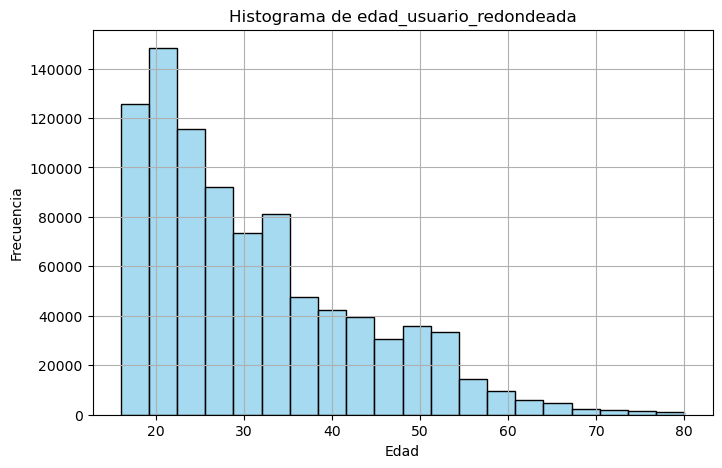

In [232]:
plt.figure(figsize=(8, 5))
sns.histplot(X_train['edad_usuario_redondeada'].dropna(), bins=20, color="skyblue")
plt.title('Histograma de edad_usuario_redondeada')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.grid(True)
plt.show()

### Imputación

A continuación, mostramos los porcentajes de nulos para las variables del dataframe resultante luego de la eliminación de columnas innecesarias


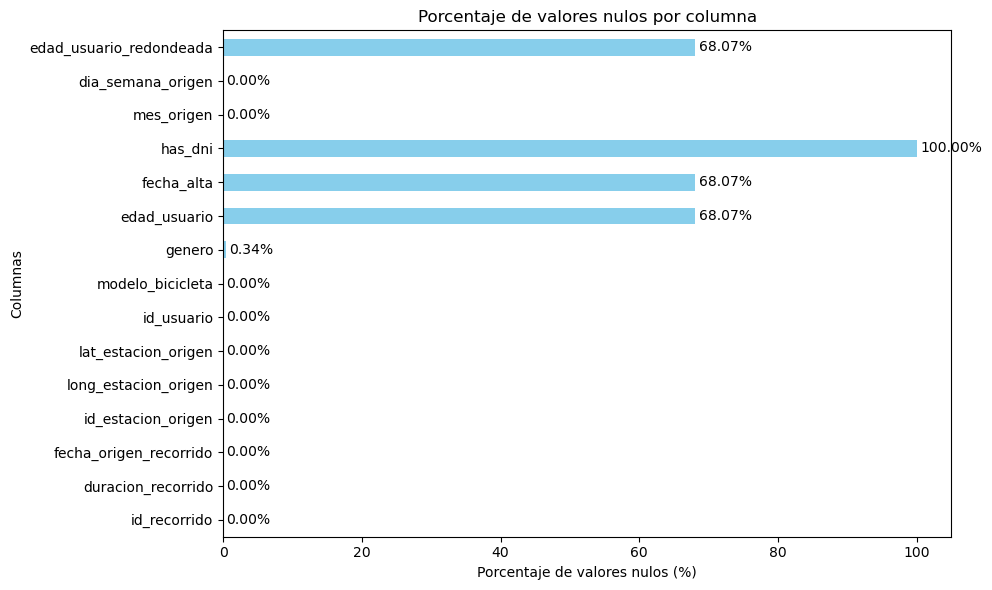

In [233]:
porcentaje_nulos = df_recorridos.isna().mean().round(4) * 100

plt.figure(figsize=(10, 6))
porcentaje_nulos.plot(kind='barh', color='skyblue')

plt.title('Porcentaje de valores nulos por columna')
plt.xlabel('Porcentaje de valores nulos (%)')
plt.ylabel('Columnas')

for index, value in enumerate(porcentaje_nulos):
    plt.text(value + 0.5, index, f'{value:.2f}%', va='center')

plt.tight_layout()
plt.show()

Observamos que para la variable has_dni, no exite ningún valor. Por lo que eliminaremos esa variable. Tambien vamos a eliminar la columna edad_usuario y vamos a quedarnos con la columna edad_usuario_redondeada.


In [234]:
X_train = X_train.drop(['has_dni'], axis=1) 
X_train = X_train.drop(['edad_usuario'], axis=1) 

X_test = X_test.drop(['has_dni'], axis=1) 
X_test = X_test.drop(['edad_usuario'], axis=1) 



Para el caso de la edad del usurio existe porcentaje alto de nulos. En este caso podríamos eliminar la columna y analizar en la etapa de modelado

Otra alternativa es discretizar por rango de edades y agregar una categoría nueva para el caso de los que tienen faltantes.  
Como la distribución de esta variable es asimétrica, decidimos usar el método por puntos de corte para discretizar.


In [235]:
# Inicializar el discretizador (4 cuantiles)
kbin = KBinsDiscretizer(n_bins=4, encode='ordinal', strategy='quantile')

# Fit con datos no nulos de X_train
kbin.fit(X_train[["edad_usuario_redondeada"]].dropna())

# Discretizamos en X_train
X_train[f'{"edad_usuario_redondeada"}_bin'] = -1  # valor para los nulos
mask_train = X_train["edad_usuario_redondeada"].notna()
X_train.loc[mask_train, f'{"edad_usuario_redondeada"}_bin'] = kbin.transform(X_train[["edad_usuario_redondeada"]][mask_train]).astype(int)

# Discretizamos en X_test
X_test[f'{"edad_usuario_redondeada"}_bin'] = -1
mask_test = X_test["edad_usuario_redondeada"].notna()
X_test.loc[mask_test, f'{"edad_usuario_redondeada"}_bin'] = kbin.transform(X_test[["edad_usuario_redondeada"]][mask_test]).astype(int)

# Eliminamos la columna edad_usuario_redondeada
X_train = X_train.drop(['edad_usuario_redondeada'], axis=1) 
X_test = X_test.drop(['edad_usuario_redondeada'], axis=1) 

In [236]:
X_train.head()

,id_recorrido,fecha_origen_recorrido,id_estacion_origen,long_estacion_origen,lat_estacion_origen,id_usuario,modelo_bicicleta,genero,fecha_alta,mes_origen,dia_semana_origen,edad_usuario_redondeada_bin
1293062,24224593,2024-12-09 15:07:50,516,-58.423347,-34.570998,1265033,FIT,OTHER,2024-12-07 07:50:07,12,Monday,1
2164055,23849178,2024-11-12 21:16:06,477,-58.395054,-34.635005,1090615,FIT,MALE,2024-01-12 01:13:23,11,Tuesday,1
3308640,20626831,2024-02-11 10:36:28,202,-58.390602,-34.583749,70757,FIT,MALE,NaT,2,Sunday,-1
1145413,23170256,2024-09-26 08:50:18,253,-58.417074,-34.616354,1200277,ICONIC,MALE,2024-09-04 10:12:17,9,Thursday,3
2834677,21503612,2024-04-23 21:37:41,150,-58.355465,-34.618755,1142457,ICONIC,FEMALE,2024-04-08 19:51:29,4,Tuesday,3


FECHA ALTA ELIMINAMOS?


En cuanto a los faltates de género, recordemos que en el tp anterior concluímos que los faltates eran de tipo MAR para esta variable. Vamos a ver la distribución por género.


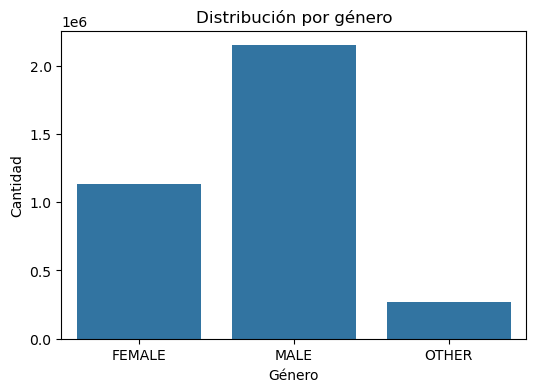

In [237]:
plt.figure(figsize=(6,4))
sns.countplot(data=df_recorridos, x='genero')
plt.title('Distribución por género')
plt.xlabel('Género')
plt.ylabel('Cantidad')
plt.show()


Dada la distribución que tienen los datos y el bajo porcentaje de faltantes para esta variable, vamos a imputar con la moda.


In [238]:
# Definimos el imputador con estrategia 'most_frequent' (moda)
imputer_gender = SimpleImputer(strategy='most_frequent')

# Ajustamos train
X_train[['genero']] = imputer_gender.fit_transform(X_train[['genero']])

# Transformamos test con lo aprendido en train
X_test[['genero']] = imputer_gender.transform(X_test[['genero']])

## Codificación

Procedemos a codificar las variables categóricas. En este caso, tenemos modelo_bicicleta, genero y dia_semana_origen. Por tratarse todas e variables categóricas de baja cardinalidad usaremos One-Hot Encoding.
